Import all the required libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

Load the dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f'Training shape {X_train.shape}')
print(f'Testing shape {X_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape (60000, 28, 28)
Testing shape (10000, 28, 28)


Visualize the image

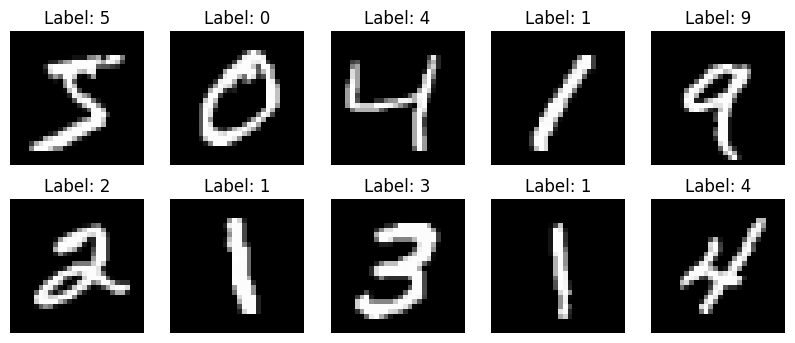

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))

for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(f'Label: {y_train[i]}')
  plt.axis('off')
plt.show()

Normalize the image

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Reshape Images

CNN expects => (num_of_images, height, weight, channels)

In [6]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


print(f'Training shape {X_train.shape}')
print(f'Testing shape {X_test.shape}')

Training shape (60000, 28, 28, 1)
Testing shape (10000, 28, 28, 1)


Build the CNN architecture

In [7]:
model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    # flatten => input layer
    Flatten(),
    # hidden layer => 128 neurons
    Dense(128, activation='relu'),
    Dropout(0.5),
    # output layer => 10 neurons
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Summary

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [9]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Model Training

In [10]:
history = model.fit(X_train, y_train, epochs = 10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.9275 - loss: 0.2388 - val_accuracy: 0.9817 - val_loss: 0.0641
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9752 - loss: 0.0852 - val_accuracy: 0.9877 - val_loss: 0.0424
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 33ms/step - accuracy: 0.9810 - loss: 0.0653 - val_accuracy: 0.9883 - val_loss: 0.0393
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - accuracy: 0.9852 - loss: 0.0499 - val_accuracy: 0.9887 - val_loss: 0.0432
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9862 - loss: 0.0426 - val_accuracy: 0.9905 - val_loss: 0.0364
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 33ms/step - accuracy: 0.9883 - loss: 0.0364 - val_accuracy: 0.9904 - val_loss: 0.0372
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.9899 - loss: 0.0313 - val_accuracy: 0.9898 - val_loss: 0.0367
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9911 -

Model Evaluation

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9923 - loss: 0.0249


In [12]:
print(f'Test loss: {loss}')
print(f'Test Accuracy: {accuracy}')

Test loss: 0.02491385117173195
Test Accuracy: 0.9922999739646912


Make Predictions

In [13]:
predictions = model.predict(X_test)
predicted_class = predictions[0].argmax()
print(f'Predicted class: {predicted_class}')
print(f'Actual class: {y_test[0]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Predicted class: 7
Actual class: 7


Display the prediction

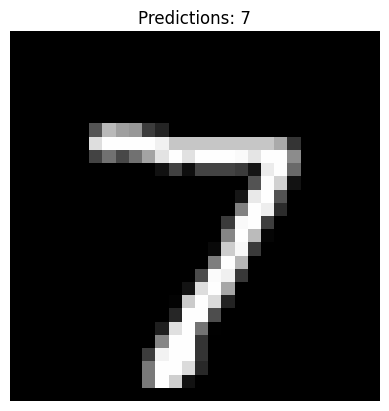

In [14]:
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title(f'Predictions: {predicted_class}')
plt.axis('off')
plt.show()

CNN Architectures 1: https://www.youtube.com/watch?v=2ogTGSrCGz8&list=PLcz9-JSejut9KkBkvSYBpb1MqbLxAjO9W&index=11

CNN Architectures 2: https://www.youtube.com/watch?v=a7tOz4q2kK8&list=PLcz9-JSejut9KkBkvSYBpb1MqbLxAjO9W&index=12&t=5731s